In [3]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset (1).csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
data = pd.read_csv("dataset.csv")
data.head()

,Maths,Biology,Creativity,Career
0,90,40,30,0
1,85,35,25,0
2,88,30,20,0
3,40,90,35,1
4,35,85,30,1


In [7]:
X = data[['Maths','Biology','Creativity']].values
y = data['Career'].values

In [8]:
y = to_categorical(y)

In [9]:
model = Sequential()

model.add(Dense(6, input_dim=3, activation='relu'))
model.add(Dense(6, activation='relu'))
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [11]:
history = model.fit(X, y, epochs=100, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 49.1673
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3333 - loss: 48.4146
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3333 - loss: 47.6660
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3333 - loss: 46.9216
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3333 - loss: 46.1813
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3333 - loss: 45.4453
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3333 - loss: 44.7136
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3333 - loss: 43.9862
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3333 - loss: 43.2633
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3333 - loss: 42.5448
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3333 - loss: 41.8307
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.

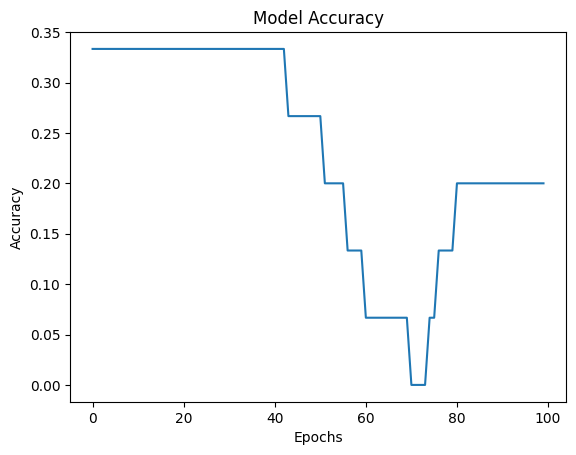

In [12]:
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [13]:
loss, accuracy = model.evaluate(X, y, verbose=0)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.20000000298023224


In [18]:
# Predict classes
y_pred = model.predict(X)
y_pred_classes = np.argmax(y_pred, axis=1)

# Original labels
y_true = np.argmax(y, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Print matrix
print("Confusion Matrix:\n")
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Confusion Matrix:

[[0 0 5]
 [2 0 3]
 [2 0 3]]


In [15]:
maths = int(input("Maths Marks: "))
biology = int(input("Biology Marks: "))
creativity = int(input("Creativity Score: "))

Maths Marks: 95
Biology Marks: 56
Creativity Score: 95


In [16]:
sample = np.array([[maths, biology, creativity]])

prediction = model.predict(sample)
career = np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


In [17]:
if career == 0:
    print("Recommended Career: Engineering")
elif career == 1:
    print("Recommended Career: Medical")
else:
    print("Recommended Career: Arts")

Recommended Career: Arts
